# ECON 5140: Applied Econometrics
## Lesson 11: Difference-in-Differences (DID)

This notebook accompanies **Lesson 11** and illustrates the core ideas from the slides:

1. **Naive vs adjusted comparison** — why we subtract the control group’s change (the Uber-style example).
2. **Canonical 2×2 DID** — treated/control × pre/post; the estimand is an **ATT**, not the ATE.
3. **Parallel trends** — what identifies DID; a case where trends differ (**bias**).
4. **Two-way fixed effects (TWFE)** regression — same DID estimand in the 2×2 case with common treatment timing.
5. **Event study vs pooled TWFE** — same state × year FE; either one post indicator (pooled) or event-time dummies for dynamics and **pre-trend** checks.
6. **Staggered adoption** — only **two** policy start dates in the demo (plus never-treated); 50 states are just repeated draws. TWFE vs simple DIDs when effects differ by adoption group (Goodman–Bacon intuition).

We use simulated data with a known treatment effect so you can compare estimators to the truth.

## Setup

In [29]:
import numpy as np
import pandas as pd
import matplotlib

try:
    get_ipython()  # noqa: F821
except NameError:
    matplotlib.use("Agg")  # script / batch runs
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

---
# Part 1: Slide intuition — naive difference vs DID
---

**Treated user:** 3 orders (Feb) → 7 (Mar): naive change **+4**.  
**Control user:** 2 → 3: change **+1**.  
**DID** = (7−3) − (3−2) = **3** — we subtract the common time trend using the control.

In [30]:
treated_pre, treated_post = 3, 7
control_pre, control_post = 2, 3

naive_treated = treated_post - treated_pre
delta_control = control_post - control_pre
did = naive_treated - delta_control

print(f"Naive change (treated only):     {naive_treated}")
print(f"Change for control:              {delta_control}")
print(f"Difference-in-differences (DID): {did}")

Naive change (treated only):     4
Change for control:              1
Difference-in-differences (DID): 3


**State policy example (slides):** State A (treated) wages 10→15; State B (control) 8→10.  
DID = (15−10) − (10−8) = **3**.

In [31]:
A_pre, A_post = 10, 15
B_pre, B_post = 8, 10
print("DID (wage example):", (A_post - A_pre) - (B_post - B_pre))

DID (wage example): 3


---
# Part 2: Simulated 2×2 panel (common treatment time)
---

Data-generating process (long panel):

$$Y_{it} = \alpha_i + \delta_t + \tau \cdot (D_i \times \mathrm{Post}_t) + \varepsilon_{it}$$

- $D_i=1$: treated unit; **Post** = 1 in the second period only.  
- In this **2×2** panel there are only two dates and treatment turns on in the second, so a separate calendar index would equal **Post**; we store **post** only.  
- Treated units have **higher baseline** $\alpha_i$ (selection on levels).  
- **Parallel trends** in the absence of treatment: both groups face the same $\delta_t$.  
- True **ATT** in the post period: $\tau$.

In [32]:
TRUE_TAU = 3.0
n_treated, n_control = 400, 400

alpha_t = np.random.normal(2.0, 1.0, n_treated)   # higher levels for treated
alpha_c = np.random.normal(0.0, 1.0, n_control)

rows = []
for i in range(n_treated):
    for post in (0, 1):
        delta_t = 0.5 * post  # common time effect; equals post in this 2×2 (only two periods)
        y = alpha_t[i] + delta_t + TRUE_TAU * post + np.random.normal(0, 0.4)
        rows.append({"unit": f"T{i}", "treated": 1, "post": post, "Y": y})
for j in range(n_control):
    for post in (0, 1):
        delta_t = 0.5 * post
        y = alpha_c[j] + delta_t + np.random.normal(0, 0.4)
        rows.append({"unit": f"C{j}", "treated": 0, "post": post, "Y": y})

df = pd.DataFrame(rows)
df["W"] = df["treated"] * df["post"]

In [33]:
df.head()

,unit,treated,post,Y,W
0,T0,1,0,2.872028,0
1,T0,1,1,5.790296,1
2,T1,1,0,1.900184,0
3,T1,1,1,5.176826,1
4,T2,1,0,2.473890,0


### 2.1 Group means and DID by hand

In [34]:
def cell_means(d):
    return (
        d.loc[(d["treated"] == 1) & (d["post"] == 0), "Y"].mean(),
        d.loc[(d["treated"] == 1) & (d["post"] == 1), "Y"].mean(),
        d.loc[(d["treated"] == 0) & (d["post"] == 0), "Y"].mean(),
        d.loc[(d["treated"] == 0) & (d["post"] == 1), "Y"].mean(),
    )


y10, y11, y00, y01 = cell_means(df)
did_manual = (y11 - y10) - (y01 - y00)
print(f"Cell means: treated (pre, post) = ({y10:.3f}, {y11:.3f})")
print(f"            control (pre, post) = ({y00:.3f}, {y01:.3f})")
print(f"DID (manual): {did_manual:.4f}   (true τ = {TRUE_TAU})")

Cell means: treated (pre, post) = (2.066, 5.549)
            control (pre, post) = (-0.059, 0.494)
DID (manual): 2.9301   (true τ = 3.0)


### 2.2 TWFE / saturated regression

With two periods and a common post indicator, **OLS with unit and time fixed effects** on $W_{it} = D_i \times \mathrm{Post}_t$ recovers the DID estimand. Equivalently, the classic **two-way demeaning** interaction:

$$Y_{it} \sim D_i + \mathrm{Post}_t + D_i \times \mathrm{Post}_t$$

identifies $\tau$ when the model is correctly specified (here it is).

In [35]:
X_sat = sm.add_constant(df[["treated", "post"]].astype(float))
X_sat["did"] = df["treated"] * df["post"]
res_sat = sm.OLS(df["Y"], X_sat).fit(cov_type="HC1")
print(res_sat.summary().tables[1])
print(f"\nCoefficient on did (TWFE/saturated): {res_sat.params['did']:.4f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0586      0.054     -1.094      0.274      -0.164       0.046
treated        2.1249      0.074     28.672      0.000       1.980       2.270
post           0.5525      0.076      7.293      0.000       0.404       0.701
did            2.9301      0.106     27.674      0.000       2.723       3.138

Coefficient on did (TWFE/saturated): 2.9301


### 2.3 Raw outcome trends (best practice: always plot)

Average $Y$ by group and period — parallel **pre** trends would extend into the post period absent treatment; the **gap** after policy is the visual DID.

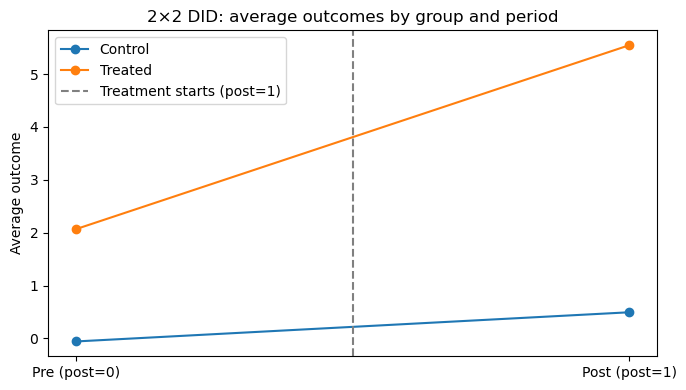

In [36]:
trend = df.groupby(["treated", "post"])["Y"].mean().unstack(0)
trend.columns = ["Control", "Treated"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trend.index, trend["Control"], "o-", label="Control")
ax.plot(trend.index, trend["Treated"], "o-", label="Treated")
ax.axvline(0.5, color="gray", linestyle="--", label="Treatment starts (post=1)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre (post=0)", "Post (post=1)"])
ax.set_ylabel("Average outcome")
ax.set_title("2×2 DID: average outcomes by group and period")
ax.legend()
plt.tight_layout()
plt.show()

---
# Part 3: When parallel trends fail
---

Suppose treated units would have grown **faster** even without treatment (differential trend). The DID estimator mixes the true $\tau$ with that **bias** term from the slides.

In [37]:
EXTRA_TREND = 1.2  # treated-specific increment to the post period (violates PT)
rows_biased = []
for i in range(n_treated):
    for post in (0, 1):
        delta_t = 0.5 * post
        extra = EXTRA_TREND * post
        y = alpha_t[i] + delta_t + TRUE_TAU * post + extra + np.random.normal(0, 0.4)
        rows_biased.append({"unit": f"T{i}", "treated": 1, "post": post, "Y": y})
for j in range(n_control):
    for post in (0, 1):
        delta_t = 0.5 * post
        y = alpha_c[j] + delta_t + np.random.normal(0, 0.4)
        rows_biased.append({"unit": f"C{j}", "treated": 0, "post": post, "Y": y})

df_bad = pd.DataFrame(rows_biased)
y10b, y11b, y00b, y01b = cell_means(df_bad)
did_bad = (y11b - y10b) - (y01b - y00b)
print(f"True τ = {TRUE_TAU}, extra differential post trend = {EXTRA_TREND}")
print(f"DID estimate (biased): {did_bad:.4f}  (expected ≈ {TRUE_TAU + EXTRA_TREND})")

True τ = 3.0, extra differential post trend = 1.2
DID estimate (biased): 4.2445  (expected ≈ 4.2)


---
# Part 4: Event study (multiple periods, common timing)
---

**Event time** $k = t - T^*$ where $T^*$ is the first treated period for treated units. We include dummies for each $k$ (omit $k=-1$). Under parallel trends, pre-treatment coefficients ($k<0$) should be near **zero**; post coefficients trace **dynamic** effects.

**Connection to TWFE:** The regressions below are **two-way fixed effects** models: they include a dummy for each **state** (one omitted) and each **year** (one omitted).

- **Pooled TWFE:** add a single indicator $W_{st} = 1\{\text{treated state } s \text{ and } t \ge T^*\}$. One coefficient summarizes *all* post-treatment years (a weighted average of dynamic effects when the true effect varies over time).
- **Event-study TWFE:** replace $W_{st}$ by dummies for each event time $k$ (relative to $k=-1$). Same state and year FE; richer dynamics and pre-trend checks.

**Real-data examples (optional replications):** classic DID/event-study settings include **Card & Krueger (1994)** (NJ/PA fast food), **Autor (2003)** (state labor rules), and many state policy panels. Replication files often appear on authors’ sites, **NBER** data listings, or journal archives. This notebook stays **synthetic** so it runs offline with no downloads.

We simulate **state–year** data to keep the regression small.


In [38]:
n_states = 40
n_treat_states = n_states // 2
years = np.arange(2005, 2021)
T_STAR = 2012

rng = np.random.default_rng(123)
state_fe = rng.normal(0, 1.5, n_states)
treated_state = np.zeros(n_states, dtype=int)
treated_state[:n_treat_states] = 1

rows_es = []
for s in range(n_states):
    for yr in years:
        year_trend = 0.08 * (yr - years.min())
        k = yr - T_STAR if treated_state[s] == 1 else np.nan
        post_effect = 0.0
        if treated_state[s] and yr >= T_STAR:
            post_effect = 2.0 + 0.15 * (yr - T_STAR)
        y = state_fe[s] + year_trend + post_effect + rng.normal(0, 0.35)
        rows_es.append(
            {
                "state": s,
                "year": yr,
                "treated": treated_state[s],
                "event_time": k,
                "Y": y,
            }
        )

es = pd.DataFrame(rows_es)
es["W"] = ((es["treated"] == 1) & (es["year"] >= T_STAR)).astype(int)


### 4.1 Pooled TWFE (single treatment indicator)

Same state and year dummies as below, plus **W** only. With a **dynamic** true effect ($2 + 0.15\times$ years since treatment), this one number is **not** equal to the effect in any single year — compare to the event-study path.


In [39]:
X_pooled = pd.get_dummies(
    es[["state", "year"]], columns=["state", "year"], drop_first=True, dtype=float
)
X_pooled["W"] = es["W"].astype(float)
fit_pooled = sm.OLS(es["Y"], X_pooled).fit(
    cov_type="cluster", cov_kwds={"groups": es["state"].astype(int)}
)
bp, sep = fit_pooled.params["W"], fit_pooled.bse["W"]
print(f"Pooled TWFE: coef on W = {bp:.4f}  (cluster SE by state = {sep:.4f})")
print("(Dynamic DGP → interpret as an average over post years, not τ at one k.)")


Pooled TWFE: coef on W = 2.5204  (cluster SE by state = 0.1050)
(Dynamic DGP → interpret as an average over post years, not τ at one k.)


### 4.2 Event-study TWFE (leads and lags)

Treatment × event-time dummies, still with state FE + year FE.


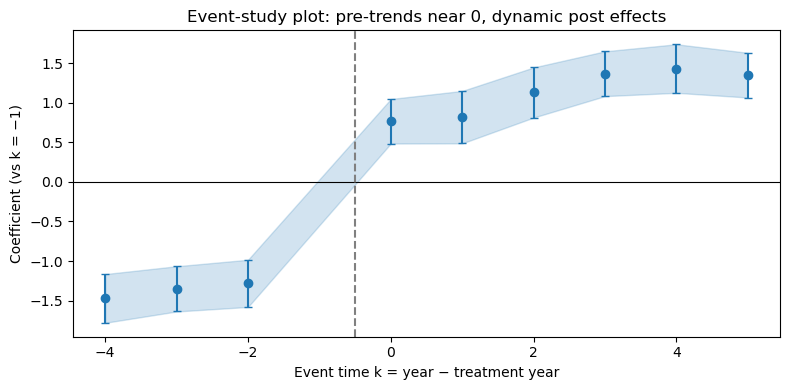

In [40]:
K_MIN, K_MAX = -4, 5
ref = -1
for k in range(K_MIN, K_MAX + 1):
    es[f"evt_{k}"] = ((es["treated"] == 1) & (es["event_time"] == k)).astype(float)

event_cols = [f"evt_{k}" for k in range(K_MIN, K_MAX + 1) if k != ref]
X_es = pd.get_dummies(es[["state", "year"]], columns=["state", "year"], drop_first=True, dtype=float)
X_es = sm.add_constant(pd.concat([X_es, es[event_cols]], axis=1))
fit_es = sm.OLS(es["Y"], X_es).fit(cov_type="HC1")

ks_plot = [k for k in range(K_MIN, K_MAX + 1) if k != ref]
betas = np.array([fit_es.params[f"evt_{k}"] for k in ks_plot])
se = np.array([fit_es.bse[f"evt_{k}"] for k in ks_plot])
ci_lo, ci_hi = betas - 1.96 * se, betas + 1.96 * se

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(-0.5, color="gray", linestyle="--", label="Treatment (k≥0)")
ax.errorbar(ks_plot, betas, yerr=1.96 * se, fmt="o", capsize=3, color="C0")
ax.fill_between(ks_plot, ci_lo, ci_hi, alpha=0.2, color="C0")
ax.set_xlabel("Event time k = year − treatment year")
ax.set_ylabel("Coefficient (vs k = −1)")
ax.set_title("Event-study plot: pre-trends near 0, dynamic post effects")
plt.tight_layout()
plt.show()


**Takeaway (slides):** passing a pre-trend check is **necessary, not sufficient** — parallel trends is about **counterfactual** paths we do not observe.

---
# Part 5: Staggered adoption — two policy dates, not “50 cohorts”
---

**Staggered** here means **two different years** when treatment turns on, plus a **never-treated** group. We use **50 states** only to get stable averages: **20** never adopt, **15** adopt in **2014**, **15** in **2017**. So there are **two treated adoption groups** (sometimes called “cohorts”); the number **50** is **not** 50 different adoption dates.

**Why TWFE can confuse:** With one regression, $Y_{st} = \alpha_s + \gamma_t + \beta D_{st} + \varepsilon_{st}$, the single $\hat\beta$ is a **mix** of many 2$\times$2 comparisons (Goodman-Bacon). If the **true** effect differs by adoption group ($\tau_{\text{early}} \neq \tau_{\text{late}}$), $\hat\beta$ may not match either group’s ATT. Below we set $\tau_{\text{early}}=3$ and $\tau_{\text{late}}=-1.5$ on purpose.

**Flow:** simulate $\rightarrow$ look at rows $\rightarrow$ **TWFE** $\rightarrow$ two **simple DIDs** vs never-treated $\rightarrow$ timing figure.


### 5.1 Simulate the state–year panel

Same recipe for every state in a group: state fixed effect + common time trend + effect after that state’s adoption year.


In [41]:
rng = np.random.default_rng(2025)
TAU_EARLY, TAU_LATE = 3.0, -1.5  # true effects differ by adoption group (opposite signs on purpose)
years = np.arange(2010, 2021)
rows = []
sid = 0

# 20 never-treated states
for _ in range(20):
    alpha = rng.normal(0, 1)
    for yr in years:
        rows.append(
            {
                "state": sid,
                "year": yr,
                "group": "never",
                "adopt_year": np.nan,
                "D": 0,
                "Y": alpha + 0.12 * (yr - years.min()) + rng.normal(0, 0.3),
            }
        )
    sid += 1

# 15 states adopt in 2014
for _ in range(15):
    alpha = rng.normal(0, 1)
    for yr in years:
        D = int(yr >= 2014)
        te = TAU_EARLY * D
        rows.append(
            {
                "state": sid,
                "year": yr,
                "group": "early_2014",
                "adopt_year": 2014,
                "D": D,
                "Y": alpha + 0.12 * (yr - years.min()) + te + rng.normal(0, 0.3),
            }
        )
    sid += 1

# 15 states adopt in 2017
for _ in range(15):
    alpha = rng.normal(0, 1)
    for yr in years:
        D = int(yr >= 2017)
        te = TAU_LATE * D
        rows.append(
            {
                "state": sid,
                "year": yr,
                "group": "late_2017",
                "adopt_year": 2017,
                "D": D,
                "Y": alpha + 0.12 * (yr - years.min()) + te + rng.normal(0, 0.3),
            }
        )
    sid += 1

stag = pd.DataFrame(rows)


### 5.2 Inspect the panel

Each row is one **(state, year)**. **D** is the policy indicator $D_{st}$ (1 from the adoption year onward for that state).


In [42]:
print(stag.shape[0], "rows =", stag["state"].nunique(), "states ×", stag["year"].nunique(), "years")
print()
print(stag.head(10).to_string(index=False))
print()
print("States per group:")
print(stag.groupby("group")["state"].nunique())


550 rows = 50 states × 11 years

 state  year group  adopt_year  D         Y
     0  2010 never         NaN  0 -2.213454
     0  2011 never         NaN  0 -2.262945
     0  2012 never         NaN  0 -2.320012
     0  2013 never         NaN  0 -2.593814
     0  2014 never         NaN  0 -1.511636
     0  2015 never         NaN  0 -1.849167
     0  2016 never         NaN  0 -1.421155
     0  2017 never         NaN  0 -1.170720
     0  2018 never         NaN  0 -1.173617
     0  2019 never         NaN  0 -1.200682

States per group:
group
early_2014    15
late_2017     15
never         20
Name: state, dtype: int64


### 5.3 Two-way fixed effects (TWFE)

OLS with state dummies, year dummies, and **D**. Standard errors clustered by state.


In [43]:
X_twfe = pd.get_dummies(
    stag[["state", "year"]], columns=["state", "year"], drop_first=True, dtype=float
)
X_twfe["D"] = stag["D"].astype(float)
fit_twfe = sm.OLS(stag["Y"], X_twfe).fit(
    cov_type="cluster", cov_kwds={"groups": stag["state"].astype(int)}
)
b, se = fit_twfe.params["D"], fit_twfe.bse["D"]
print(f"TWFE coefficient on D = {b:.4f}   (cluster SE = {se:.4f})")
print(f"Built-in truth: tau_early = {TAU_EARLY},  tau_late = {TAU_LATE}")
print("→ One pooled coefficient need not equal either tau when effects differ by adoption group.")


TWFE coefficient on D = 0.9105   (cluster SE = 0.3658)
Built-in truth: tau_early = 3.0,  tau_late = -1.5
→ One pooled coefficient need not equal either tau when effects differ by adoption group.


### 5.4 Simple DID using only never-treated states

We compute two **plain** DIDs with **never-treated** as control:

- **Early adopters (2014):** pre 2010–2013 vs post 2014–2016 (late adopters are still off; we do not use them as controls here).
- **Late adopters (2017):** pre 2010–2016 vs post 2017–2020.

These should track the $\tau$s we coded in; the TWFE coefficient above does not have to.


In [44]:
def did_vs_never(df, treat_group, pre_years, post_years):
    tr = df["group"] == treat_group
    nv = df["group"] == "never"
    pre_t = df.loc[tr & df["year"].isin(pre_years), "Y"].mean()
    post_t = df.loc[tr & df["year"].isin(post_years), "Y"].mean()
    pre_c = df.loc[nv & df["year"].isin(pre_years), "Y"].mean()
    post_c = df.loc[nv & df["year"].isin(post_years), "Y"].mean()
    return (post_t - pre_t) - (post_c - pre_c)


did_early = did_vs_never(stag, "early_2014", range(2010, 2014), range(2014, 2017))
did_late = did_vs_never(stag, "late_2017", range(2010, 2017), range(2017, 2021))
print(f"DID early vs never:  {did_early:.4f}   (target {TAU_EARLY})")
print(f"DID late vs never:   {did_late:.4f}   (target {TAU_LATE})")


DID early vs never:  2.9143   (target 3.0)
DID late vs never:   -1.4495   (target -1.5)


### 5.5 When is $D_{st}=1$? (schematic)

One row each: never, adopt-2014, adopt-2017.


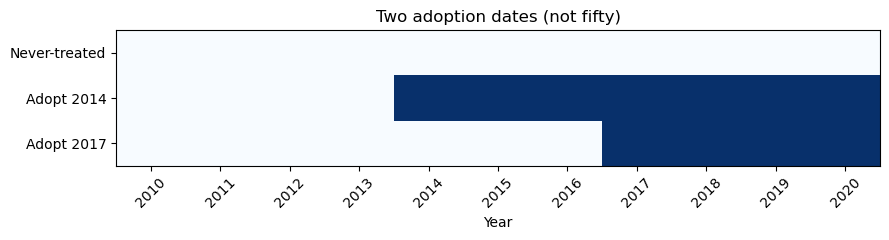

In [45]:
labels = ["Never-treated", "Adopt 2014", "Adopt 2017"]
year_grid = np.arange(2010, 2021)
D_demo = np.zeros((3, len(year_grid)))
D_demo[1, year_grid >= 2014] = 1
D_demo[2, year_grid >= 2017] = 1

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.imshow(D_demo, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_yticks(range(3), labels)
ax.set_xticks(np.arange(len(year_grid)), year_grid, rotation=45)
ax.set_xlabel("Year")
ax.set_title("Two adoption dates (not fifty)")
plt.tight_layout()
plt.show()


**Takeaway:** There are only **two adoption years** in this exercise; **50** counts **states**, not fifty timing patterns. With staggered timing and different true effects, interpret a single TWFE coefficient cautiously; show **who is treated when**, **trends**, and group-specific or modern estimators (e.g. Callaway & Sant’Anna) when needed.
